Лабороторна робота №2

Ознайомитись з описом датасета, визначити цільову змінну (target) та основну задачу прогнозної моделі. 
Виконати попередню обробку даних з метою подальшої побудови моделі. Можна використовувати ту інформацію, котру ви отримали в результаті виконання завдань Лабораторної роботи №1.


In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('adult.csv')

In [2]:
data_info = data.info()
data_head = data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [3]:
columns_to_check = ['workclass', 'occupation', 'native-country', 'income']
unique_values = {col: data[col].unique() for col in columns_to_check}

missing_data = data.isnull().sum()
print(unique_values) 
print(missing_data)

{'workclass': array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object), 'occupation': array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?',
       'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical',
       'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv',
       'Transport-moving', 'Handlers-cleaners', 'Armed-Forces'],
      dtype=object), 'native-country': array(['United-States', '?', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobag

In [4]:
data_cleaned = data.replace('?', np.nan)
data_cleaned['income'] = data_cleaned['income'].apply(lambda x: 1 if x == '>50K' else 0)
data_dropped = data_cleaned.dropna()

In [7]:
data_cleaned = data_dropped.drop(columns=['educational-num'])

import numpy as np

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in data_cleaned.select_dtypes(include=np.number).columns:
    data_cleaned = remove_outliers(data_cleaned, col)

Логістична регресія

In [ ]:
from sklearn.model_selection import train_test_split

X = data_cleaned.drop('income', axis=1)
y = data_cleaned['income']

# Розділення на тренувальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [7]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier', LogisticRegression())])

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.80
Precision: 0.72
Recall: 0.27
F1 Score: 0.39


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

Cs = np.logspace(-4, 4, 10)

model_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l2', solver='liblinear', max_iter=5000))
])

model_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', max_iter=5000))
])

model_elasticnet = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000))
])

param_grid_ridge = {'classifier__C': Cs}
param_grid_lasso = {'classifier__C': Cs}
param_grid_elasticnet = {'classifier__C': Cs, 'classifier__l1_ratio': [0.5]}

grid_ridge = GridSearchCV(model_ridge, param_grid_ridge, cv=5, scoring='accuracy', n_jobs=-1)
grid_lasso = GridSearchCV(model_lasso, param_grid_lasso, cv=5, scoring='accuracy', n_jobs=-1)
grid_elasticnet = GridSearchCV(model_elasticnet, param_grid_elasticnet, cv=5, scoring='accuracy', n_jobs=-1)

grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)
grid_elasticnet.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_
best_lasso = grid_lasso.best_estimator_
best_elasticnet = grid_elasticnet.best_estimator_
print(f'Best rigde :{best_ridge}')
print(f'Best lasso :{best_lasso}')
print(f'Best elasticnet :{best_elasticnet}')


Best rigde :Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(C=0.3593813663804626, max_iter=5000,
                                    solver='liblinear'))])
Best lasso :Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['age', 'fnlwgt', '

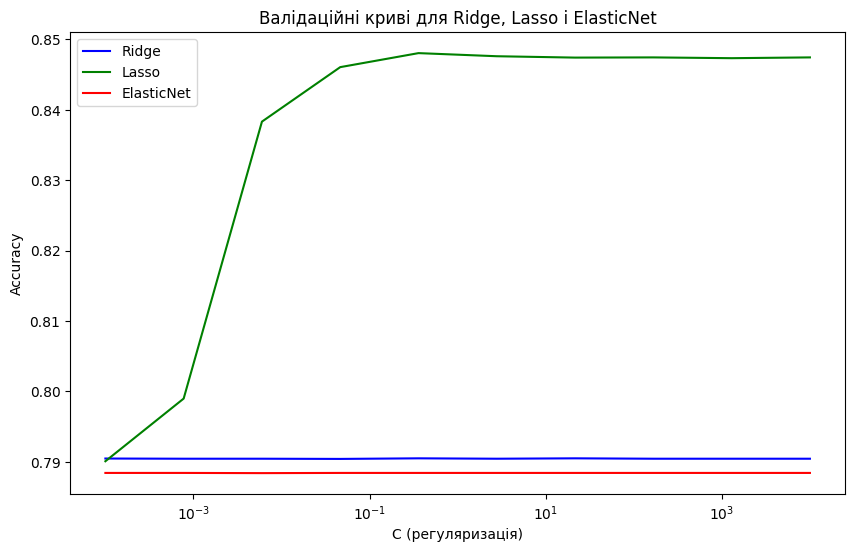

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(Cs, grid_ridge.cv_results_['mean_test_score'], label='Ridge', color='blue')
plt.plot(Cs, grid_lasso.cv_results_['mean_test_score'], label='Lasso', color='green')
plt.plot(Cs, grid_elasticnet.cv_results_['mean_test_score'], label='ElasticNet', color='red')
plt.xscale('log')
plt.xlabel('регуляризація')
plt.ylabel('Accuracy')
plt.title('Валідаційні криві для Ridge, Lasso і ElasticNet')
plt.legend()
plt.show()

In [15]:
y_pred_ridge = best_ridge.predict(X_test)
y_pred_lasso = best_lasso.predict(X_test)
y_pred_elasticnet = best_elasticnet.predict(X_test)

def evaluate_model(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

ridge_results = evaluate_model(y_test, y_pred_ridge)
lasso_results = evaluate_model(y_test, y_pred_lasso)
elasticnet_results = evaluate_model(y_test, y_pred_elasticnet)

print(f'Ridge: Accuracy: {ridge_results[0]:.2f}, Precision: {ridge_results[1]:.2f}, Recall: {ridge_results[2]:.2f}, F1: {ridge_results[3]:.2f}')
print(f'Lasso: Accuracy: {lasso_results[0]:.2f}, Precision: {lasso_results[1]:.2f}, Recall: {lasso_results[2]:.2f}, F1: {lasso_results[3]:.2f}')
print(f'ElasticNet: Accuracy: {elasticnet_results[0]:.2f}, Precision: {elasticnet_results[1]:.2f}, Recall: {elasticnet_results[2]:.2f}, F1: {elasticnet_results[3]:.2f}')


Ridge: Accuracy: 0.80, Precision: 0.72, Recall: 0.26, F1: 0.39
Lasso: Accuracy: 0.85, Precision: 0.75, Recall: 0.60, F1: 0.66
ElasticNet: Accuracy: 0.79, Precision: 0.71, Recall: 0.26, F1: 0.38


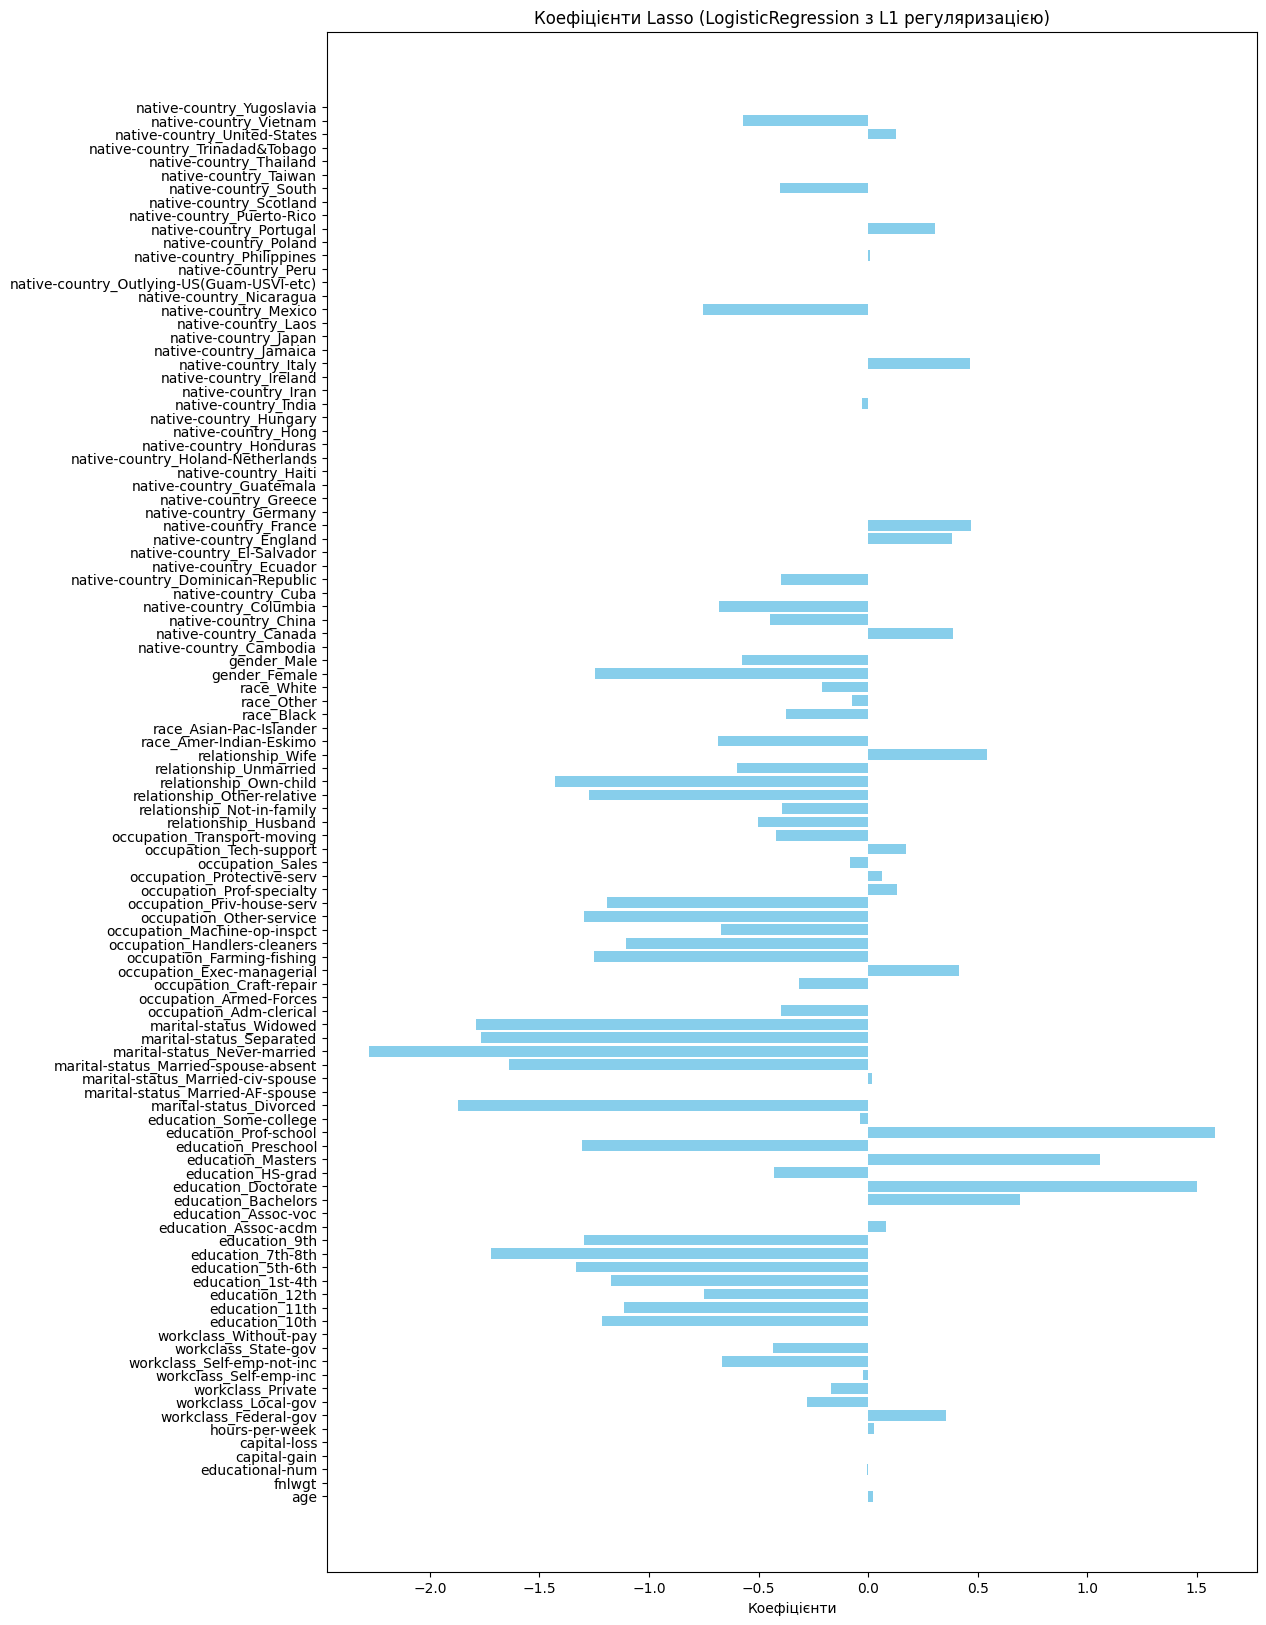

In [20]:
lasso_coefficients = best_lasso.named_steps['classifier'].coef_[0]

encoded_feature_names = best_lasso.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numeric_cols, encoded_feature_names])

plt.figure(figsize=(12, 20))
plt.barh(all_feature_names, lasso_coefficients, color='skyblue')
plt.xlabel('Коефіцієнти')
plt.title('Коефіцієнти Lasso')
plt.show()


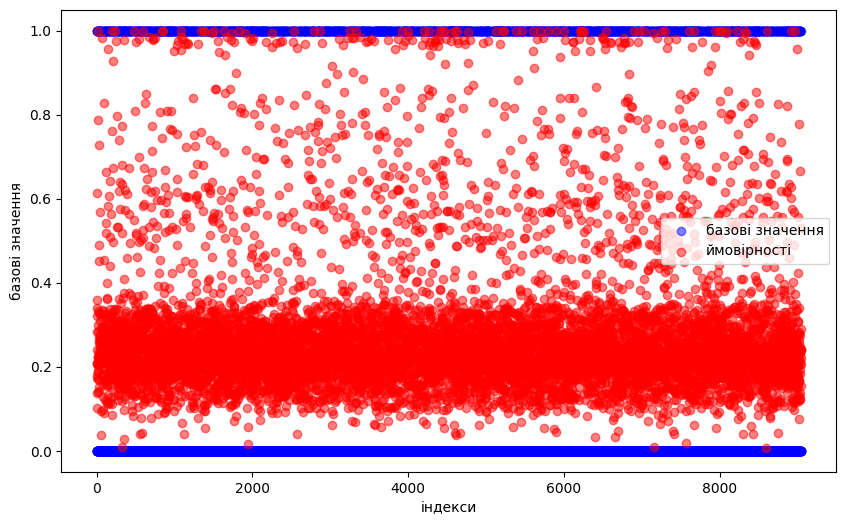

In [11]:
y_pred_prob = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='базові значення', alpha=0.5)
plt.scatter(range(len(y_pred_prob)), y_pred_prob, color='red', label='ймовірності', alpha=0.5)
plt.xlabel('індекси')
plt.ylabel('базові значення')
plt.legend()
plt.show()


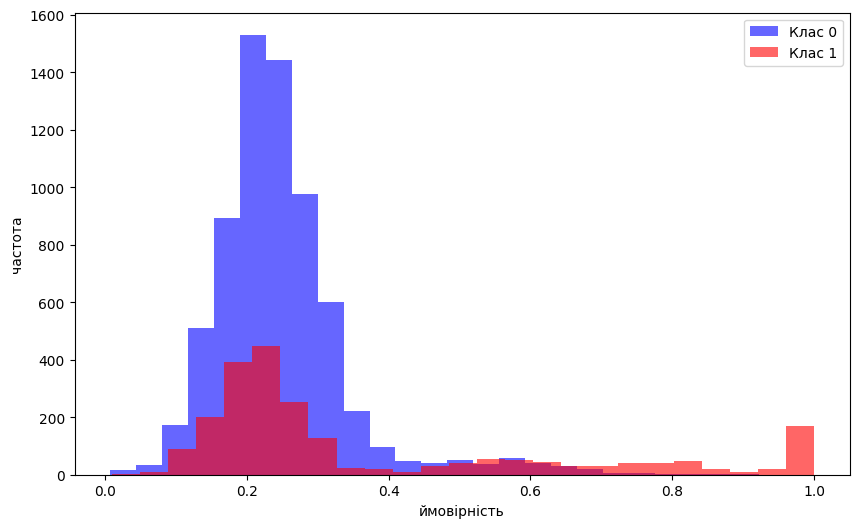

In [13]:

plt.figure(figsize=(10, 6))

# Гістограма передбачених ймовірностей для класу 0
plt.hist(y_pred_prob[y_test == 0], bins=25, alpha=0.6, color='blue', label='Клас 0')

# Гістограма передбачених ймовірностей для класу 1
plt.hist(y_pred_prob[y_test == 1], bins=25, alpha=0.6, color='red', label='Клас 1')

plt.xlabel('ймовірність')
plt.ylabel('частота')
plt.legend()
plt.show()